In [ ]:

!pip install yfinance


In [ ]:
df = yf.download("EURUSD=X", interval="1m", period="7d")
df.dropna(inplace=True)

# Explicitly rename columns to standard OHLCV labels
# This assumes yfinance returns data for 5 columns in this order: Open, High, Low, Close, Volume.
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# 🔄 Convert to 5-minute candles
df_5m = df.resample('5T').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

df_5m.dropna(inplace=True)

df = df_5m

print("Dataset size:", len(df))

/tmp/ipykernel_14068/2183613279.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("EURUSD=X", interval="1m", period="7d")
[*********************100%***********************]  1 of 1 completed

Dataset size: 1885



/tmp/ipykernel_14068/2183613279.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df.resample('5T').agg({


In [ ]:
df.shape

(1885, 5)

In [ ]:
print(len(df))

1885


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
df.to_csv('financial_data.csv')


In [ ]:
# MACD
df['EMA12'] = df['Close'].ewm(span=12).mean()
df['EMA26'] = df['Close'].ewm(span=26).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9).mean()

# Alligator
df['Jaw'] = df['Close'].rolling(13).mean().shift(8)
df['Teeth'] = df['Close'].rolling(8).mean().shift(5)
df['Lips'] = df['Close'].rolling(5).mean().shift(3)

df.dropna(inplace=True)


In [ ]:
features = ['Close', 'MACD', 'Signal', 'Jaw', 'Teeth', 'Lips']
data = df[features]


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [ ]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])  # predict Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
model = Sequential()

#  CNN layers (DEEP)
model.add(Conv1D(64, 3, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Conv1D(128, 3, activation='relu'))
model.add(Conv1D(256, 3, activation='relu'))
model.add(Dropout(0.2))

# LSTM + GRU
model.add(LSTM(128, return_sequences=True))
model.add(GRU(128))

#  Dense
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - loss: 0.0252 - val_loss: 0.0259
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 264ms/step - loss: 0.0026 - val_loss: 0.0080
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 359ms/step - loss: 0.0021 - val_loss: 0.0054
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - loss: 0.0015 - val_loss: 0.0036
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - loss: 0.0018 - val_loss: 0.0038
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - loss: 0.0014 - val_loss: 0.0040
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - loss: 0.0013 - val_loss: 0.0025
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - loss: 0.0013 - val_loss: 0.0036
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - loss: 0.0013 - val_loss: 0.0061
Epoch 10/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - loss: 0.0014 - val_loss: 0.0051
Epoch 11/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - loss: 0.0012 - val_loss: 0.0043
Epoch 12/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s

In [ ]:
y_pred = model.predict(X_test)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 56, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 54, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 54, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 54, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,981 (4.91 MB)

 Trainable params: 428,993 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 857,988 (3.27 MB)

In [ ]:
# pad predictions to match scaler shape
dummy = np.zeros((len(y_pred), scaled_data.shape[1]))
dummy[:, 0] = y_pred[:, 0]

y_pred_inv = scaler.inverse_transform(dummy)[:, 0]

dummy[:, 0] = y_test
y_test_inv = scaler.inverse_transform(dummy)[:, 0]


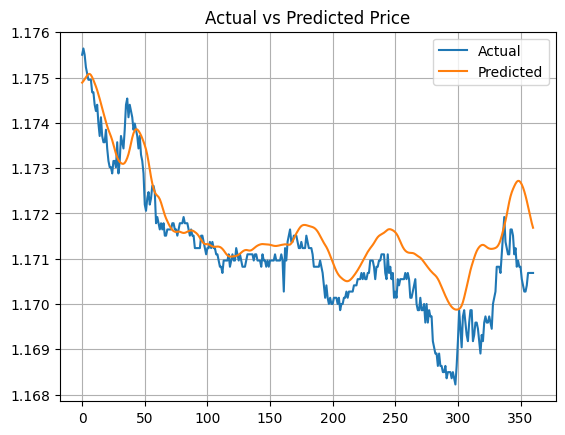

In [ ]:
plt.figure()
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.grid()
plt.savefig("price_prediction.png")
plt.show()


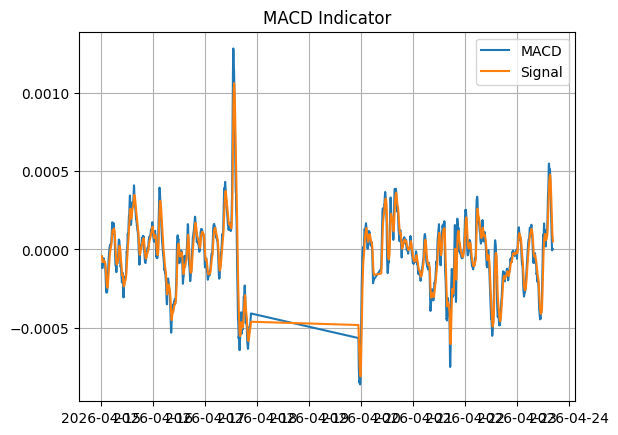

In [ ]:
plt.figure()
plt.plot(df['MACD'], label='MACD')
plt.plot(df['Signal'], label='Signal')
plt.title('MACD Indicator')
plt.legend()
plt.grid()
plt.savefig("macd.png")
plt.show()


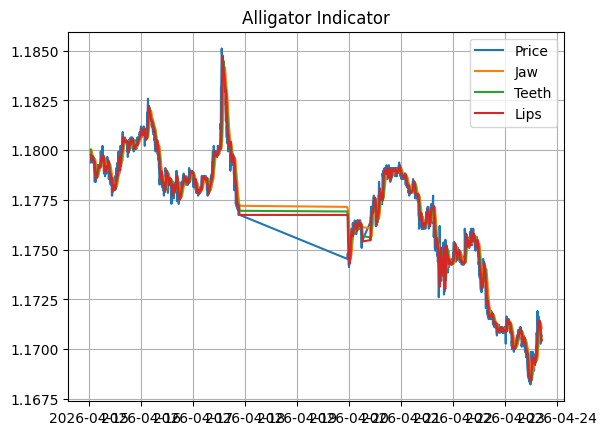

In [ ]:
plt.figure()
plt.plot(df['Close'], label='Price')
plt.plot(df['Jaw'], label='Jaw')
plt.plot(df['Teeth'], label='Teeth')
plt.plot(df['Lips'], label='Lips')
plt.title('Alligator Indicator')
plt.legend()
plt.grid()
plt.savefig("alligator.png")
plt.show()


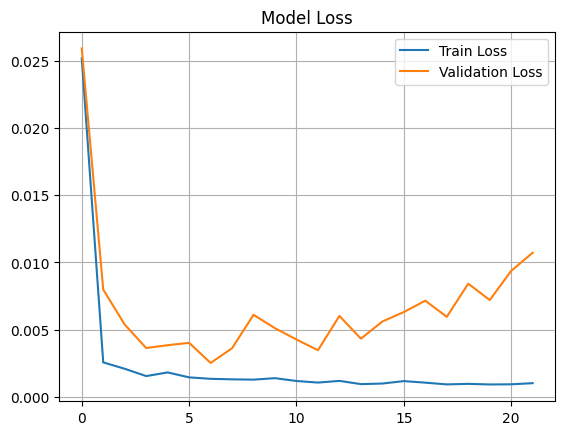

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.savefig("loss.png")
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R2 Score: {r2:.5f}")


RMSE: 0.00085
MAE: 0.00065
R2 Score: 0.64454
